In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display


In [3]:
# Organize Data by State

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Iowa"]
state_tracts
state_tracts.to_csv("state_tracs_Iowa.csv")

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Kansas"]
state_tracts
state_tracts.to_csv("state_tracs_Kansas.csv")

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Oklahoma"]
state_tracts
state_tracts.to_csv("state_tracs_Oklahoma.csv")

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Missouri"]
state_tracts
state_tracts.to_csv("state_tracs_Missouri.csv")

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Arkansas"]
state_tracts
state_tracts.to_csv("state_tracs_Arkansas.csv")

all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts = all_tracts[all_tracts["STATE"] == "Nebraska"]
state_tracts
state_tracts.to_csv("state_tracs_Nebraska.csv")

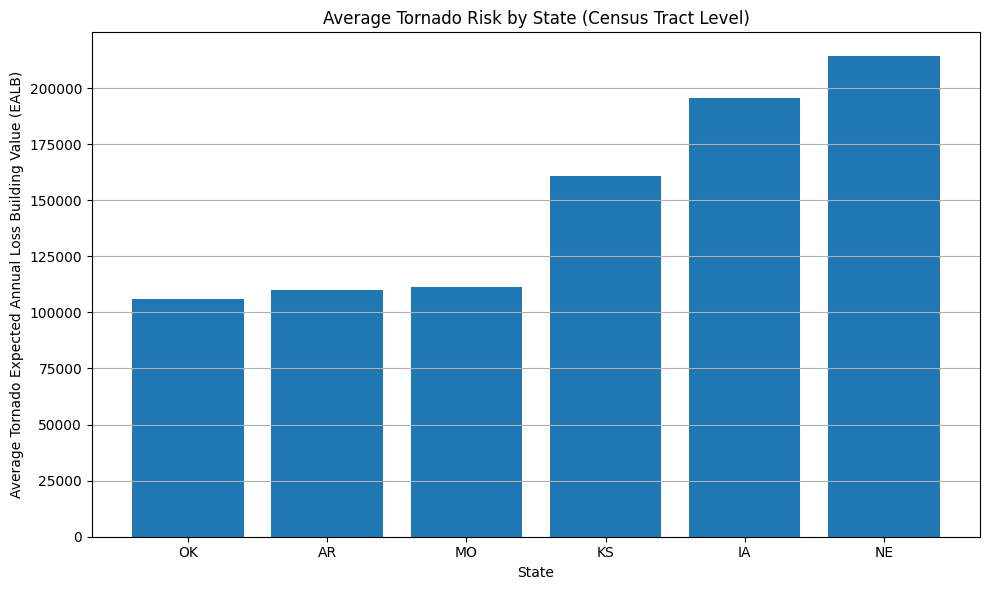

In [4]:
# Step 1: Load the dataset
# Replace with your actual file path
df = pd.read_csv("NRI_Table_CensusTracts.csv")

# Step 2: Select relevant states
states = ["NE", "KS", "OK", "MO", "IA", "AR"]

df_states = df[df["STATEABBRV"].isin(states)]

# Step 3: Clean data (remove missing or zero values if needed)
df_states = df_states[df_states["TRND_EALB"].notna()]

# remove extreme outliers if they exist
df_states = df_states[df_states["TRND_EALB"] < df_states["TRND_EALB"].quantile(0.99)]

# Step 4: Group by state and compute mean tornado risk
state_risk = df_states.groupby("STATEABBRV")["TRND_EALB"].mean()

# Step 5: Sort values for better visualization
state_risk = state_risk.sort_values()

# Step 6: Plot
plt.figure(figsize=(10,6))
plt.bar(state_risk.index, state_risk.values)

# Labels and title
plt.xlabel("State")
plt.ylabel("Average Tornado Expected Annual Loss Building Value (EALB)")
plt.title("Average Tornado Risk by State (Census Tract Level)")

# Optional: rotate labels if needed
plt.xticks(rotation=0)

# Grid for readability
plt.grid(axis='y')

plt.tight_layout()
plt.show()

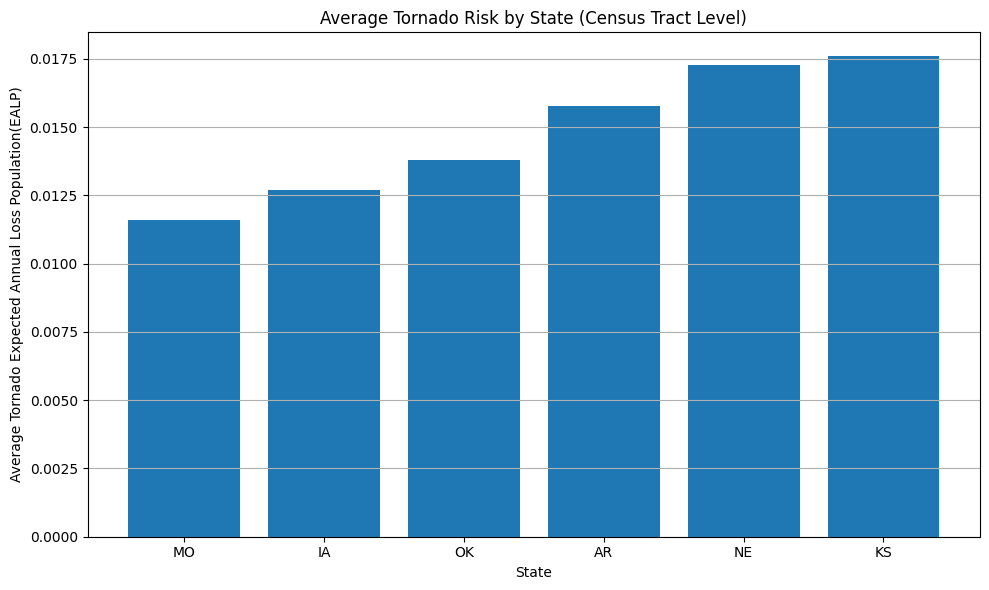

In [5]:
df = pd.read_csv("NRI_Table_CensusTracts.csv")

# Step 2: Select relevant states
states = ["NE", "KS", "OK", "MO", "IA", "AR"]

df_states = df[df["STATEABBRV"].isin(states)]

# Step 3: Clean data (remove missing or zero values if needed)
df_states = df_states[df_states["TRND_EALP"].notna()]

# remove extreme outliers if they exist
df_states = df_states[df_states["TRND_EALP"] < df_states["TRND_EALP"].quantile(0.99)]

# Step 4: Group by state and compute mean tornado risk
state_risk = df_states.groupby("STATEABBRV")["TRND_EALP"].mean()

# Step 5: Sort values for better visualization
state_risk = state_risk.sort_values()

# Step 6: Plot
plt.figure(figsize=(10,6))
plt.bar(state_risk.index, state_risk.values)

# Labels and title
plt.xlabel("State")
plt.ylabel("Average Tornado Expected Annual Loss Population(EALP)")
plt.title("Average Tornado Risk by State (Census Tract Level)")

# Optional: rotate labels if needed
plt.xticks(rotation=0)

# Grid for readability
plt.grid(axis='y')

plt.tight_layout()
plt.show()

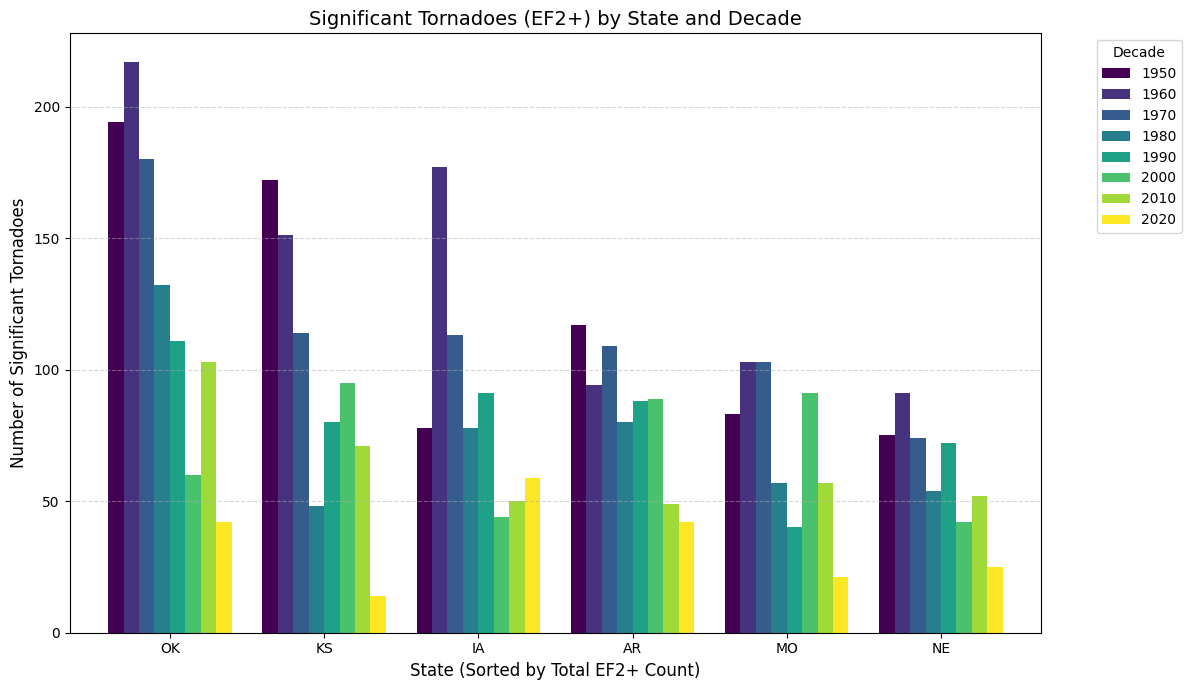

In [6]:
# Load the SPC data
df = pd.read_csv("Tornado_Data.csv")

# 1. Filter for Significant Tornadoes (EF2+) to remove reporting bias
# Note: 'mag' is the column for F/EF scale
df_sig = df[df['mag'] >= 2].copy()

# 2. Filter for your target states
target_states = ["NE", "KS", "OK", "MO", "IA", "AR"]
df_filtered = df_sig[df_sig["st"].isin(target_states)].copy()

# 3. Create decade column
df_filtered['decade'] = (df_filtered['yr'] // 10) * 10

# 4. Count by state and decade
plot_data = df_filtered.groupby(['st', 'decade']).size().unstack(fill_value=0)

# 5. Sort states by total significant tornado count (Total strength/activity)
state_order = plot_data.sum(axis=1).sort_values(ascending=False).index
plot_data = plot_data.loc[state_order]

# 6. Plot
ax = plot_data.plot(kind='bar', figsize=(12, 7), width=0.8, colormap='viridis')

plt.title("Significant Tornadoes (EF2+) by State and Decade", fontsize=14)
plt.xlabel("State (Sorted by Total EF2+ Count)", fontsize=12)
plt.ylabel("Number of Significant Tornadoes", fontsize=12)
plt.legend(title="Decade", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

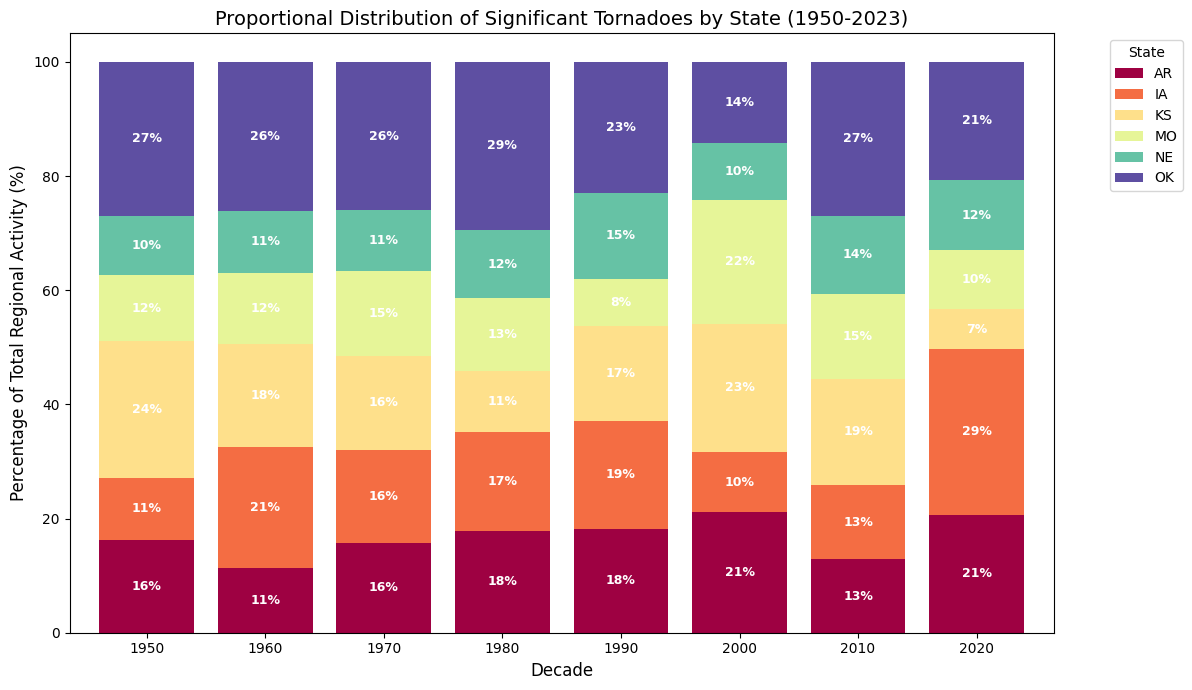

In [6]:
# Load the SPC data
df = pd.read_csv("Tornado_Data.csv")

# 1. Filter for Significant Tornadoes (EF2+) and your target states
target_states = ["NE", "KS", "OK", "MO", "IA", "AR"]
df_research = df[(df['mag'] >= 2) & (df['st'].isin(target_states))].copy()

# 2. Create decade column
df_research['decade'] = (df_research['yr'] // 10) * 10

# 3. Create a pivot table: Rows = Decade, Columns = States
pivot_df = df_research.groupby(['decade', 'st']).size().unstack(fill_value=0)

# 4. Normalize the data to 100% (Proportional distribution)
# Divide each row by its sum
pivot_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 5. Plot 100% Stacked Bar Chart
ax = pivot_perc.plot(kind='bar', stacked=True, figsize=(12, 7), width=0.8, colormap='Spectral')

# Formatting
plt.title("Proportional Distribution of Significant Tornadoes by State (1950-2023)", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Percentage of Total Regional Activity (%)", fontsize=12)
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Add percentage labels to the bars for clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Only show label if segment is large enough
        x, y = p.get_xy() 
        # Changed 'cm' to 'ha' (horizontal alignment)
        ax.text(x + width/2, y + height/2, f'{height:.0f}%', 
                ha='center', va='center', fontsize=9, 
                color='white', fontweight='bold')

plt.tight_layout()
plt.show()

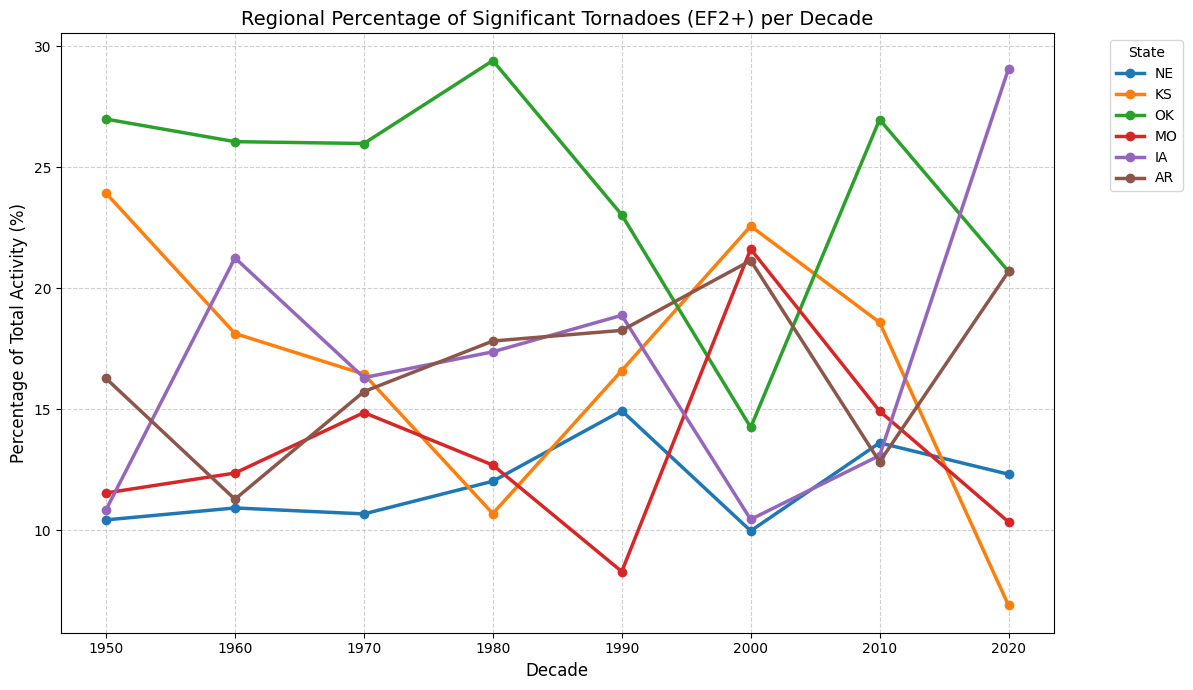

In [7]:
df = pd.read_csv("Tornado_Data.csv")

target_states = ["NE", "KS", "OK", "MO", "IA", "AR"]
df_research = df[(df['mag'] >= 2) & (df['st'].isin(target_states))].copy()
df_research['decade'] = (df_research['yr'] // 10) * 10

pivot_df = df_research.groupby(['decade', 'st']).size().unstack(fill_value=0)
pivot_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))
for state in target_states:
    if state in pivot_perc.columns:
        plt.plot(pivot_perc.index, pivot_perc[state], marker='o', label=state, linewidth=2.5)

plt.title("Regional Percentage of Significant Tornadoes (EF2+) per Decade", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Percentage of Total Activity (%)", fontsize=12)
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(pivot_perc.index)

plt.tight_layout()
plt.show()

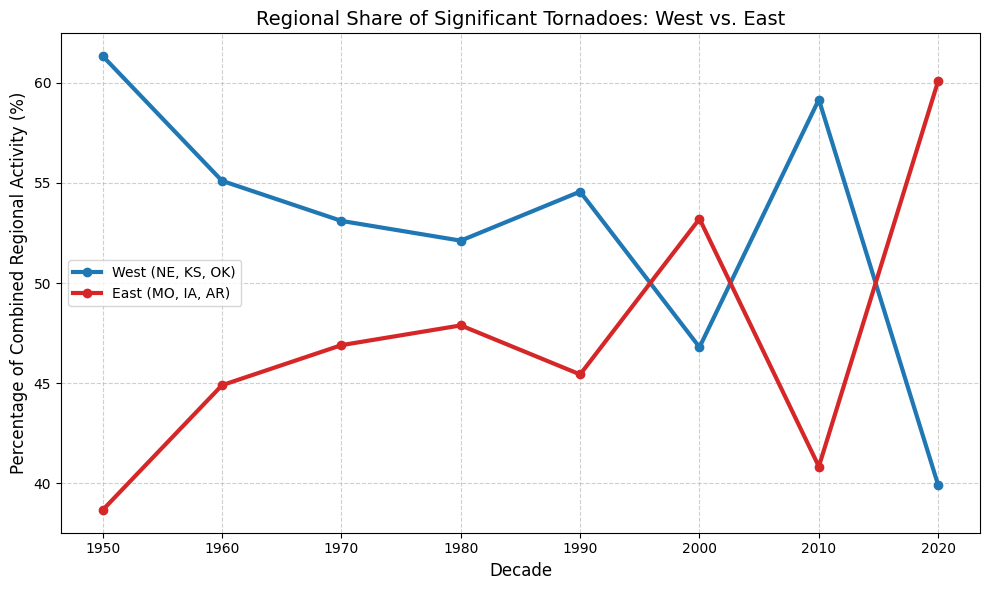

region  East (Mississippi Valley)  West (Plains)
decade                                          
1950                        38.66          61.34
1960                        44.90          55.10
1970                        46.90          53.10
1980                        47.88          52.12
1990                        45.44          54.56
2000                        53.21          46.79
2010                        40.84          59.16
2020                        60.10          39.90


In [9]:
# Define regions
west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]

# Filter significant tornadoes
df_sig = df[df['mag'] >= 2].copy()
df_sig['decade'] = (df_sig['yr'] // 10) * 10

# Assign regions
def assign_region(st):
    if st in west_states: return "West (Plains)"
    if st in east_states: return "East (Mississippi Valley)"
    return None

df_sig['region'] = df_sig['st'].apply(assign_region)
df_regional = df_sig.dropna(subset=['region'])

# Calculate percentages
regional_counts = df_regional.groupby(['decade', 'region']).size().unstack(fill_value=0)
regional_perc = regional_counts.div(regional_counts.sum(axis=1), axis=0) * 100

# Plot
plt.figure(figsize=(10, 6))
plt.plot(regional_perc.index, regional_perc["West (Plains)"], marker='o', label="West (NE, KS, OK)", linewidth=3, color='tab:blue')
plt.plot(regional_perc.index, regional_perc["East (Mississippi Valley)"], marker='o', label="East (MO, IA, AR)", linewidth=3, color='tab:red')

plt.title("Regional Share of Significant Tornadoes: West vs. East", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Percentage of Combined Regional Activity (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(regional_perc.index)

plt.tight_layout()
plt.show()

print(regional_perc.round(2))

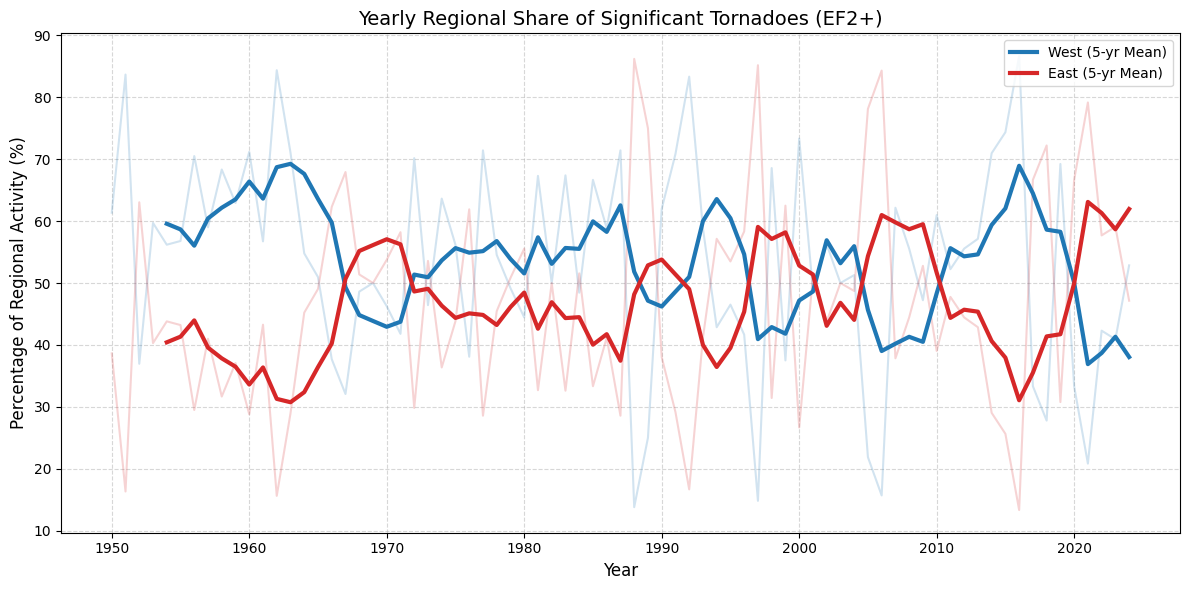

In [10]:

df = pd.read_csv("Tornado_Data.csv")

west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]

df_sig = df[df['mag'] >= 2].copy()

def assign_region(st):
    if st in west_states: return "West (Plains)"
    if st in east_states: return "East (Mississippi Valley)"
    return None

df_sig['region'] = df_sig['st'].apply(assign_region)
df_regional = df_sig.dropna(subset=['region'])

# Group by year
yearly_counts = df_regional.groupby(['yr', 'region']).size().unstack(fill_value=0)
yearly_perc = yearly_counts.div(yearly_counts.sum(axis=1), axis=0) * 100

# Calculate 5-year rolling average to smooth noise
rolling_perc = yearly_perc.rolling(window=5).mean()

plt.figure(figsize=(12, 6))

# Plot raw yearly data (faint lines)
plt.plot(yearly_perc.index, yearly_perc["West (Plains)"], color='tab:blue', alpha=0.2)
plt.plot(yearly_perc.index, yearly_perc["East (Mississippi Valley)"], color='tab:red', alpha=0.2)

# Plot rolling averages (bold lines)
plt.plot(rolling_perc.index, rolling_perc["West (Plains)"], label="West (5-yr Mean)", color='tab:blue', linewidth=3)
plt.plot(rolling_perc.index, rolling_perc["East (Mississippi Valley)"], label="East (5-yr Mean)", color='tab:red', linewidth=3)

plt.title("Yearly Regional Share of Significant Tornadoes (EF2+)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage of Regional Activity (%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

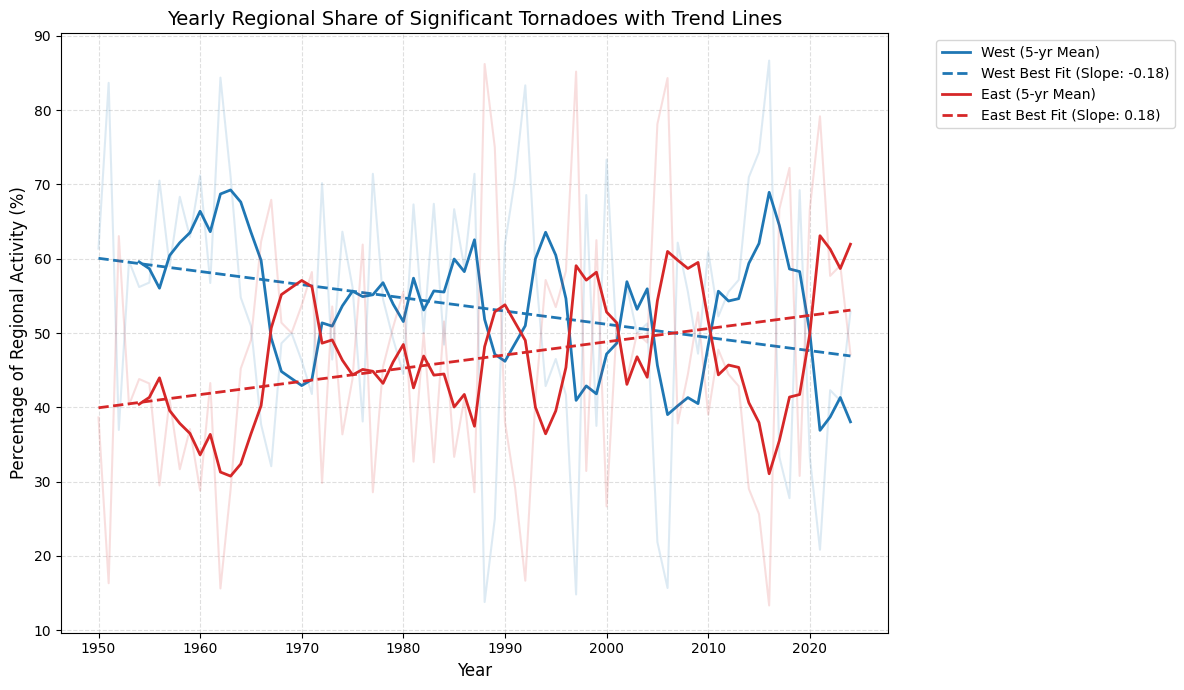

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Tornado_Data.csv")

west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]

df_sig = df[df['mag'] >= 2].copy()

def assign_region(st):
    if st in west_states: return "West"
    if st in east_states: return "East"
    return None

df_sig['region'] = df_sig['st'].apply(assign_region)
df_regional = df_sig.dropna(subset=['region'])

# Calculate yearly regional percentages
yearly_counts = df_regional.groupby(['yr', 'region']).size().unstack(fill_value=0)
yearly_perc = yearly_counts.div(yearly_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))

for region, color in zip(["West", "East"], ["tab:blue", "tab:red"]):
    y = yearly_perc[region]
    x = yearly_perc.index
    
    # Plot raw data (faint)
    plt.plot(x, y, color=color, alpha=0.15)
    
    # 5-year rolling average (bold)
    plt.plot(x, y.rolling(window=5).mean(), color=color, linewidth=2, label=f"{region} (5-yr Mean)")
    
    # Line of Best Fit
    z = np.polyfit(x, y, 1) # 1 for linear
    p = np.poly1d(z)
    plt.plot(x, p(x), color=color, linestyle="--", linewidth=2, label=f"{region} Best Fit (Slope: {z[0]:.2f})")

plt.title("Yearly Regional Share of Significant Tornadoes with Trend Lines", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage of Regional Activity (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [12]:
# Filter specifically for 'Violent' Tornadoes (EF4 and EF5)
df_violent = df[df['mag'] >= 4].copy()
df_violent['decade'] = (df_violent['yr'] // 10) * 10

# Regional Comparison
violent_counts = df_violent[df_violent['st'].isin(["NE", "KS", "OK", "MO", "IA", "AR"])]
violent_trend = violent_counts.groupby(['decade', 'st']).size().unstack(fill_value=0)

# Check if the 'East' states are starting to see more of these 
print("Historical EF4/EF5 counts by state and decade:")
print(violent_trend)

Historical EF4/EF5 counts by state and decade:
st      AR  IA  KS  MO  NE  OK
decade                        
1950     6  11  17  12  10  20
1960     5  17  10   8   8  13
1970     2   9   3  11   6  14
1980     5   9   3   5   4   6
1990     8   6  10   1   3   8
2000     1   1  10   9   3   4
2010     2   3   4   5   5   9
2020     1   3   0   1   2   3


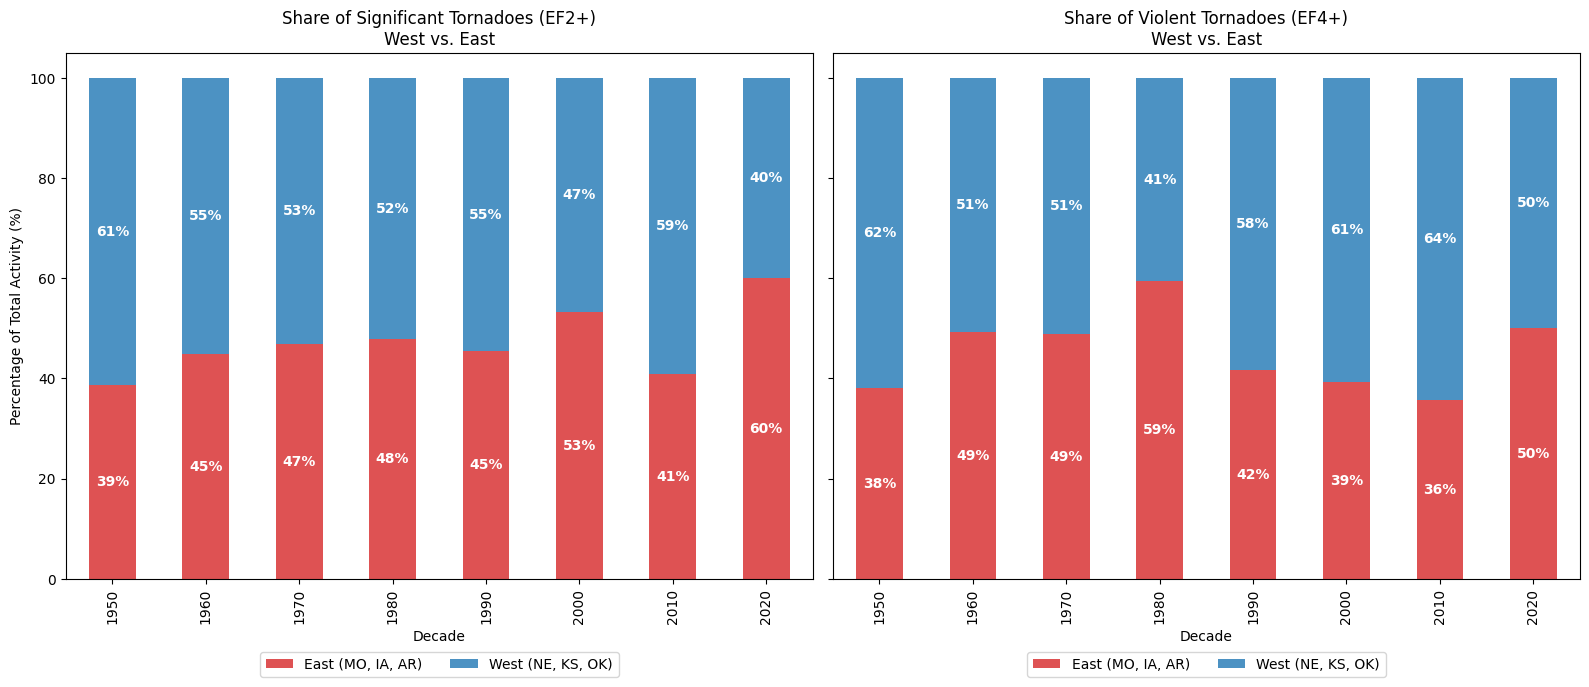

In [13]:


df = pd.read_csv("Tornado_Data.csv")

west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]

def get_proportions(min_mag):
    df_filtered = df[(df['mag'] >= min_mag) & (df['st'].isin(west_states + east_states))].copy()
    df_filtered['decade'] = (df_filtered['yr'] // 10) * 10
    df_filtered['region'] = df_filtered['st'].apply(lambda x: 'West' if x in west_states else 'East')
    
    counts = df_filtered.groupby(['decade', 'region']).size().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0) * 100

# Calculate for both intensity levels
prop_ef2 = get_proportions(2)
prop_ef4 = get_proportions(4)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

prop_ef2.plot(kind='bar', stacked=True, ax=ax1, color=['tab:red', 'tab:blue'], alpha=0.8)
ax1.set_title("Share of Significant Tornadoes (EF2+)\nWest vs. East", fontsize=12)
ax1.set_ylabel("Percentage of Total Activity (%)")

prop_ef4.plot(kind='bar', stacked=True, ax=ax2, color=['tab:red', 'tab:blue'], alpha=0.8)
ax2.set_title("Share of Violent Tornadoes (EF4+)\nWest vs. East", fontsize=12)

# Add labels
for ax in [ax1, ax2]:
    ax.set_xlabel("Decade")
    ax.legend(["East (MO, IA, AR)", "West (NE, KS, OK)"], loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
    for p in ax.patches:
        h = p.get_height()
        if h > 5:
            ax.text(p.get_x() + p.get_width()/2, p.get_y() + h/2, f'{h:.0f}%', 
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

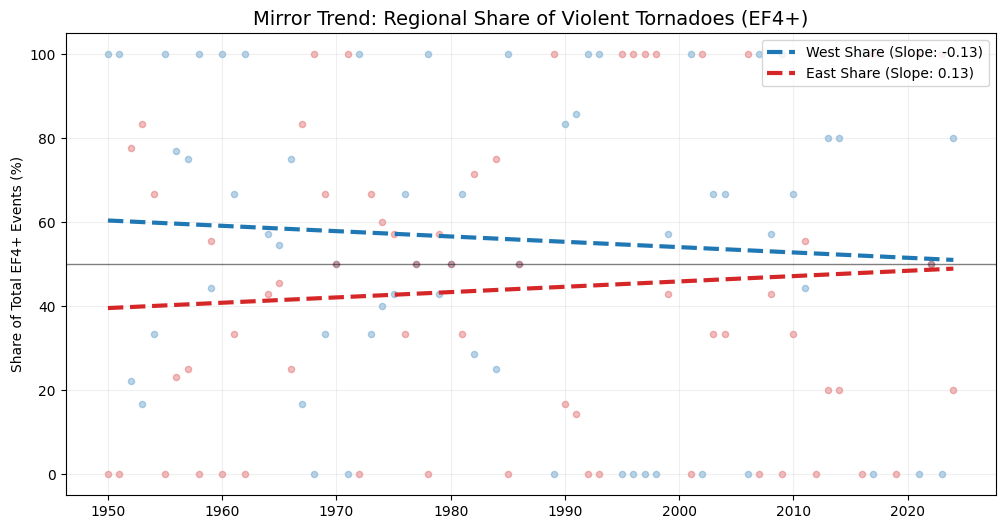

In [16]:
# 1. Define Regions
west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]
all_target_states = west_states + east_states

# 2. Filter for EF4+ in ONLY these states
df_sig = df[(df['mag'] >= 4) & (df['st'].isin(all_target_states))].copy()

# 3. Create Yearly Counts
yearly = df_sig.groupby(['yr', 'st']).size().unstack(fill_value=0)

# 4. Sum by Region
final_df = pd.DataFrame(index=yearly.index)
final_df['West_Count'] = yearly[west_states].sum(axis=1)
final_df['East_Count'] = yearly[east_states].sum(axis=1)
final_df['Total_Regional'] = final_df['West_Count'] + final_df['East_Count']

# 5. CRITICAL: Remove years with 0 total tornadoes to fix the mirror
# If we keep 0-count years, both lines drop to 0 and ruin the trend
mirror_df = final_df[final_df['Total_Regional'] > 0].copy()

# 6. Calculate Percentages (Now they will sum to 100%)
mirror_df['West_Perc'] = (mirror_df['West_Count'] / mirror_df['Total_Regional']) * 100
mirror_df['East_Perc'] = (mirror_df['East_Count'] / mirror_df['Total_Regional']) * 100

# 7. Plot
plt.figure(figsize=(12, 6))
for col, label, color in [('West_Perc', 'West Share', 'tab:blue'), 
                          ('East_Perc', 'East Share', 'tab:red')]:
    x = mirror_df.index
    y = mirror_df[col]
    
    # Scatter points
    plt.scatter(x, y, color=color, alpha=0.3, s=20)
    
    # Line of Best Fit
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), color=color, linestyle="--", linewidth=3, 
             label=f"{label} (Slope: {z[0]:.2f})")

plt.axhline(50, color='black', linewidth=1, alpha=0.5) # The "Balance" Line
plt.title("Mirror Trend: Regional Share of Violent Tornadoes (EF4+)", fontsize=14)
plt.ylabel("Share of Total EF4+ Events (%)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

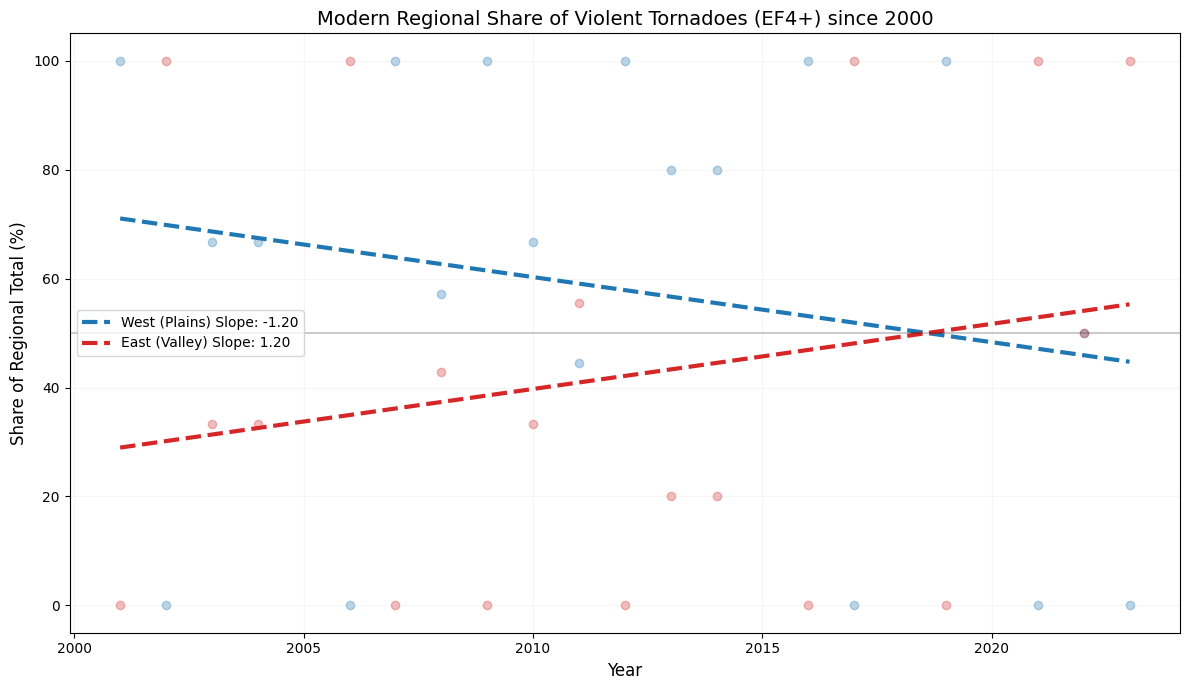

In [17]:
# Load the SPC data
df = pd.read_csv("Tornado_Data.csv")

# 1. Setup Regions and Filters
west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]
all_target_states = west_states + east_states

# 2. Filter for EF4+ since 2000
df_modern = df[(df['yr'] >= 2000) & (df['mag'] >= 4) & (df['st'].isin(all_target_states))].copy()

# 3. Aggregate by Year and Region
yearly = df_modern.groupby(['yr', 'st']).size().unstack(fill_value=0)

# Create a clean DataFrame for just the two regions
final_df = pd.DataFrame(index=range(2000, 2024))
final_df['West_Count'] = yearly[yearly.columns.intersection(west_states)].sum(axis=1)
final_df['East_Count'] = yearly[yearly.columns.intersection(east_states)].sum(axis=1)
final_df['Total'] = final_df['West_Count'] + final_df['East_Count']

# 4. Filter for years where at least one violent tornado occurred in these 6 states
# This is crucial for the "Mirror" effect
mirror_df = final_df[final_df['Total'] > 0].copy()

# 5. Calculate Percentage Share
mirror_df['West_Share'] = (mirror_df['West_Count'] / mirror_df['Total']) * 100
mirror_df['East_Share'] = (mirror_df['East_Count'] / mirror_df['Total']) * 100

# 6. Plot
plt.figure(figsize=(12, 7))
x = mirror_df.index

for col, label, color in [('West_Share', 'West (Plains)', 'tab:blue'), 
                          ('East_Share', 'East (Valley)', 'tab:red')]:
    y = mirror_df[col]
    
    # Scatter points for raw annual share
    plt.scatter(x, y, color=color, alpha=0.3)
    
    # Line of Best Fit
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), color=color, linestyle="--", linewidth=3, 
             label=f"{label} Slope: {z[0]:.2f}")

plt.axhline(50, color='black', alpha=0.2, linestyle='-') # 50/50 balance line
plt.title("Modern Regional Share of Violent Tornadoes (EF4+) since 2000", fontsize=14)
plt.ylabel("Share of Regional Total (%)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

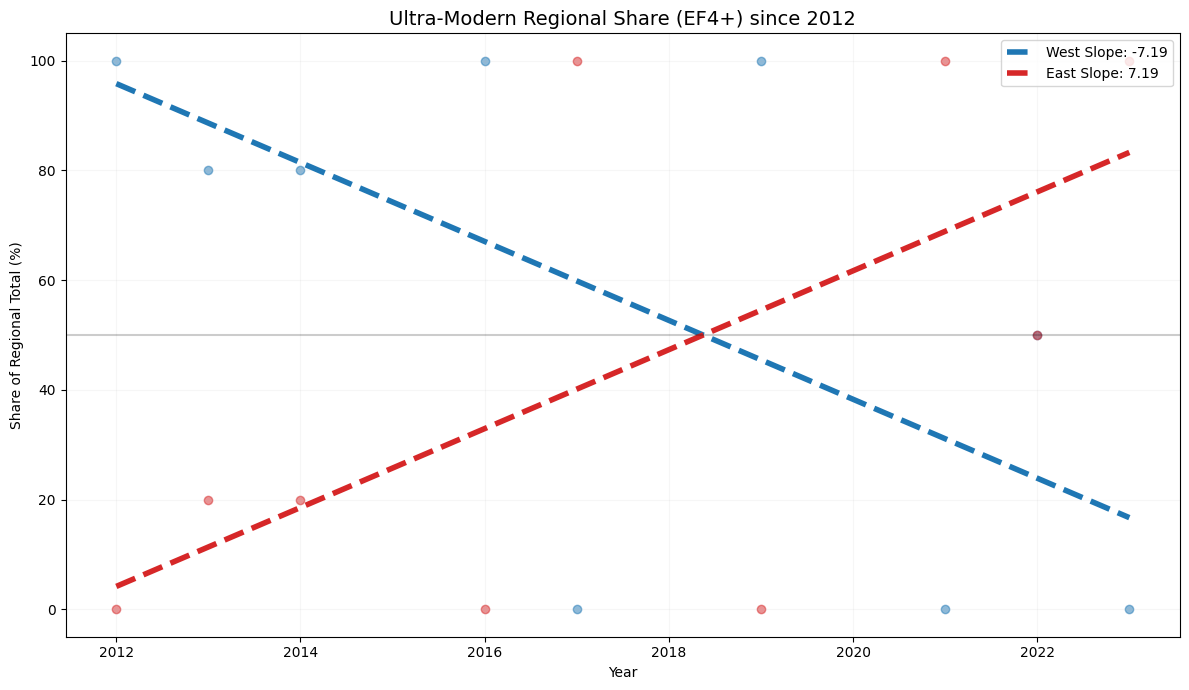

In [18]:
# Load the SPC data
df = pd.read_csv("Tornado_Data.csv")

# 1. Setup Regions
west_states = ["NE", "KS", "OK"]
east_states = ["MO", "IA", "AR"]
all_target_states = west_states + east_states

# 2. Filter for EF4+ since 2012
df_ultra = df[(df['yr'] >= 2012) & (df['mag'] >= 4) & (df['st'].isin(all_target_states))].copy()

# 3. Aggregate
yearly = df_ultra.groupby(['yr', 'st']).size().unstack(fill_value=0)
final_df = pd.DataFrame(index=range(2012, 2024))
final_df['West_Count'] = yearly[yearly.columns.intersection(west_states)].sum(axis=1)
final_df['East_Count'] = yearly[yearly.columns.intersection(east_states)].sum(axis=1)
final_df['Total'] = final_df['West_Count'] + final_df['East_Count']

# 4. Mirror logic: Only years with at least one event in these 6 states
mirror_df = final_df[final_df['Total'] > 0].copy()
mirror_df['West_Share'] = (mirror_df['West_Count'] / mirror_df['Total']) * 100
mirror_df['East_Share'] = (mirror_df['East_Count'] / mirror_df['Total']) * 100

# 5. Plot
plt.figure(figsize=(12, 7))
x = mirror_df.index

for col, label, color in [('West_Share', 'West', 'tab:blue'), ('East_Share', 'East', 'tab:red')]:
    y = mirror_df[col]
    plt.scatter(x, y, color=color, alpha=0.5)
    
    # Line of Best Fit
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), color=color, linestyle="--", linewidth=4, 
             label=f"{label} Slope: {z[0]:.2f}")

plt.axhline(50, color='black', alpha=0.2)
plt.title("Ultra-Modern Regional Share (EF4+) since 2012", fontsize=14)
plt.ylabel("Share of Regional Total (%)")
plt.xlabel("Year")
plt.legend()
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()